In [1]:
# ==================== IMPORT LIBRARIES ====================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("Libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print("="*70)

Libraries loaded successfully!
TensorFlow version: 2.18.0
OpenCV version: 4.12.0


In [2]:
# ==================== LOAD & FILTER DATASET ====================
"""
Scan dataset dan filter hanya Cataract & Normal
"""
print("="*70)
print("LOADING DATASET")
print("="*70)

# Dataset path
data_dir = "dataset" 

def create_dataframe(data_dir, target_classes=['cataract', 'normal']):
    """
    Scan dataset dan ambil hanya Cataract dan Normal
    """
    filepaths = []
    labels = []
    
    print("\nScanning folders...")
    all_folders = os.listdir(data_dir)
    print(f"Found: {all_folders}")
    
    # Filter target folders
    target_folders = [f for f in all_folders 
                      if any(t in f.lower() for t in target_classes)]
    print(f"\n✓ Filtered to: {target_folders}")
    
    # Collect files
    for folder in target_folders:
        folder_path = os.path.join(data_dir, folder)
        if os.path.isdir(folder_path):
            files = [f for f in os.listdir(folder_path) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            print(f"  {folder}: {len(files)} images")
            
            for file in files:
                filepaths.append(os.path.join(folder_path, file))
                labels.append('Cataract' if 'cataract' in folder.lower() else 'Normal')
    
    # Create DataFrame
    df = pd.DataFrame({
        'filepaths': filepaths,
        'labels': labels
    })
    
    return df

# Load data
df = create_dataframe(data_dir)

print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df['labels'].value_counts())
print(f"\nBalance ratio: {df['labels'].value_counts().min() / df['labels'].value_counts().max():.2%}")
print("="*70)

LOADING DATASET

Scanning folders...
Found: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

✓ Filtered to: ['cataract', 'normal']
  cataract: 1038 images
  normal: 1074 images

DATASET SUMMARY
Total images: 2112

Class distribution:
labels
Normal      1074
Cataract    1038
Name: count, dtype: int64

Balance ratio: 96.65%


In [3]:
# ==================== SPLIT DATASET (70-15-15) ====================
"""
Split dataset:
- 70% Train
- 15% Validation  
- 15% Test
"""
print("="*70)
print("SPLITTING DATASET (70-15-15)")
print("="*70)

# First split: 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3,
    stratify=df['labels'],
    random_state=42
)

# Second split: 50-50 dari 30% = 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['labels'],
    random_state=42
)

# Verify splits
print("\n📊 SPLIT SUMMARY")
print("="*70)
print(f"Total dataset: {len(df)} images\n")

print(f"Train:      {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(train_df['labels'].value_counts())

print(f"\nValidation:  {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(val_df['labels'].value_counts())

print(f"\nTest:        {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")
print(test_df['labels'].value_counts())

# Check for data leakage
train_files = set(train_df['filepaths'])
val_files = set(val_df['filepaths'])
test_files = set(test_df['filepaths'])

if not (train_files & val_files) and not (train_files & test_files) and not (val_files & test_files):
    print("\n✅ Tidak Ada Kebocoran Data!")
else:
    print("\n⚠️  WARNING: Ada kebocoran data antar split!")

print("\n" + "="*70)
print("SPLIT STATISTICS")
print("="*70)
print(f"Train samples:      {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples:  {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test samples:        {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
print("="*70)

SPLITTING DATASET (70-15-15)

📊 SPLIT SUMMARY
Total dataset: 2112 images

Train:      1478 images (70.0%)
labels
Normal      752
Cataract    726
Name: count, dtype: int64

Validation:  317 images (15.0%)
labels
Normal      161
Cataract    156
Name: count, dtype: int64

Test:        317 images (15.0%)
labels
Normal      161
Cataract    156
Name: count, dtype: int64

✅ Tidak Ada Kebocoran Data!

SPLIT STATISTICS
Train samples:      1478 (70.0%)
Validation samples:  317 (15.0%)
Test samples:        317 (15.0%)


In [20]:
# ==================== IMAGE PREPROCESSING & AUGMENTATION ====================
"""
Setup data augmentation dan preprocessing untuk training
"""
print("="*70)
print("DATA PREPROCESSING & AUGMENTATION")
print("="*70)

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"\nImage size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

# Data Augmentation for TRAINING only
print("\n📸 Training Augmentation:")
print("  • Rotation: ±20°")
print("  • Width/Height shift: 5%")
print("  • Shear: 5%")
print("  • Zoom: 5%")
print("  • Horizontal flip")
print("  • Brightness: 80-120%")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='constant'
)

# ONLY rescaling for validation & test
print("\n📸 Validation & Test:")
print("  • Only rescale (1/255)")

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
print("\nCreating data generators...")

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n✓ Data generators created successfully!")
print(f"  • Train batches: {len(train_gen)}")
print(f"  • Val batches: {len(val_gen)}")
print(f"  • Test batches: {len(test_gen)}")
print("="*70)

DATA PREPROCESSING & AUGMENTATION

Image size: (224, 224)
Batch size: 32

📸 Training Augmentation:
  • Rotation: ±20°
  • Width/Height shift: 5%
  • Shear: 5%
  • Zoom: 5%
  • Horizontal flip
  • Brightness: 80-120%

📸 Validation & Test:
  • Only rescale (1/255)

Creating data generators...
Found 1478 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.
Found 317 validated image filenames belonging to 2 classes.

✓ Data generators created successfully!
  • Train batches: 47
  • Val batches: 10
  • Test batches: 10


VISUALISASI DATA SETELAH AUGMENTASI

📊 Generating augmentation visualization...
   Showing 3 samples × 5 versions (1 original + 4 augmented)



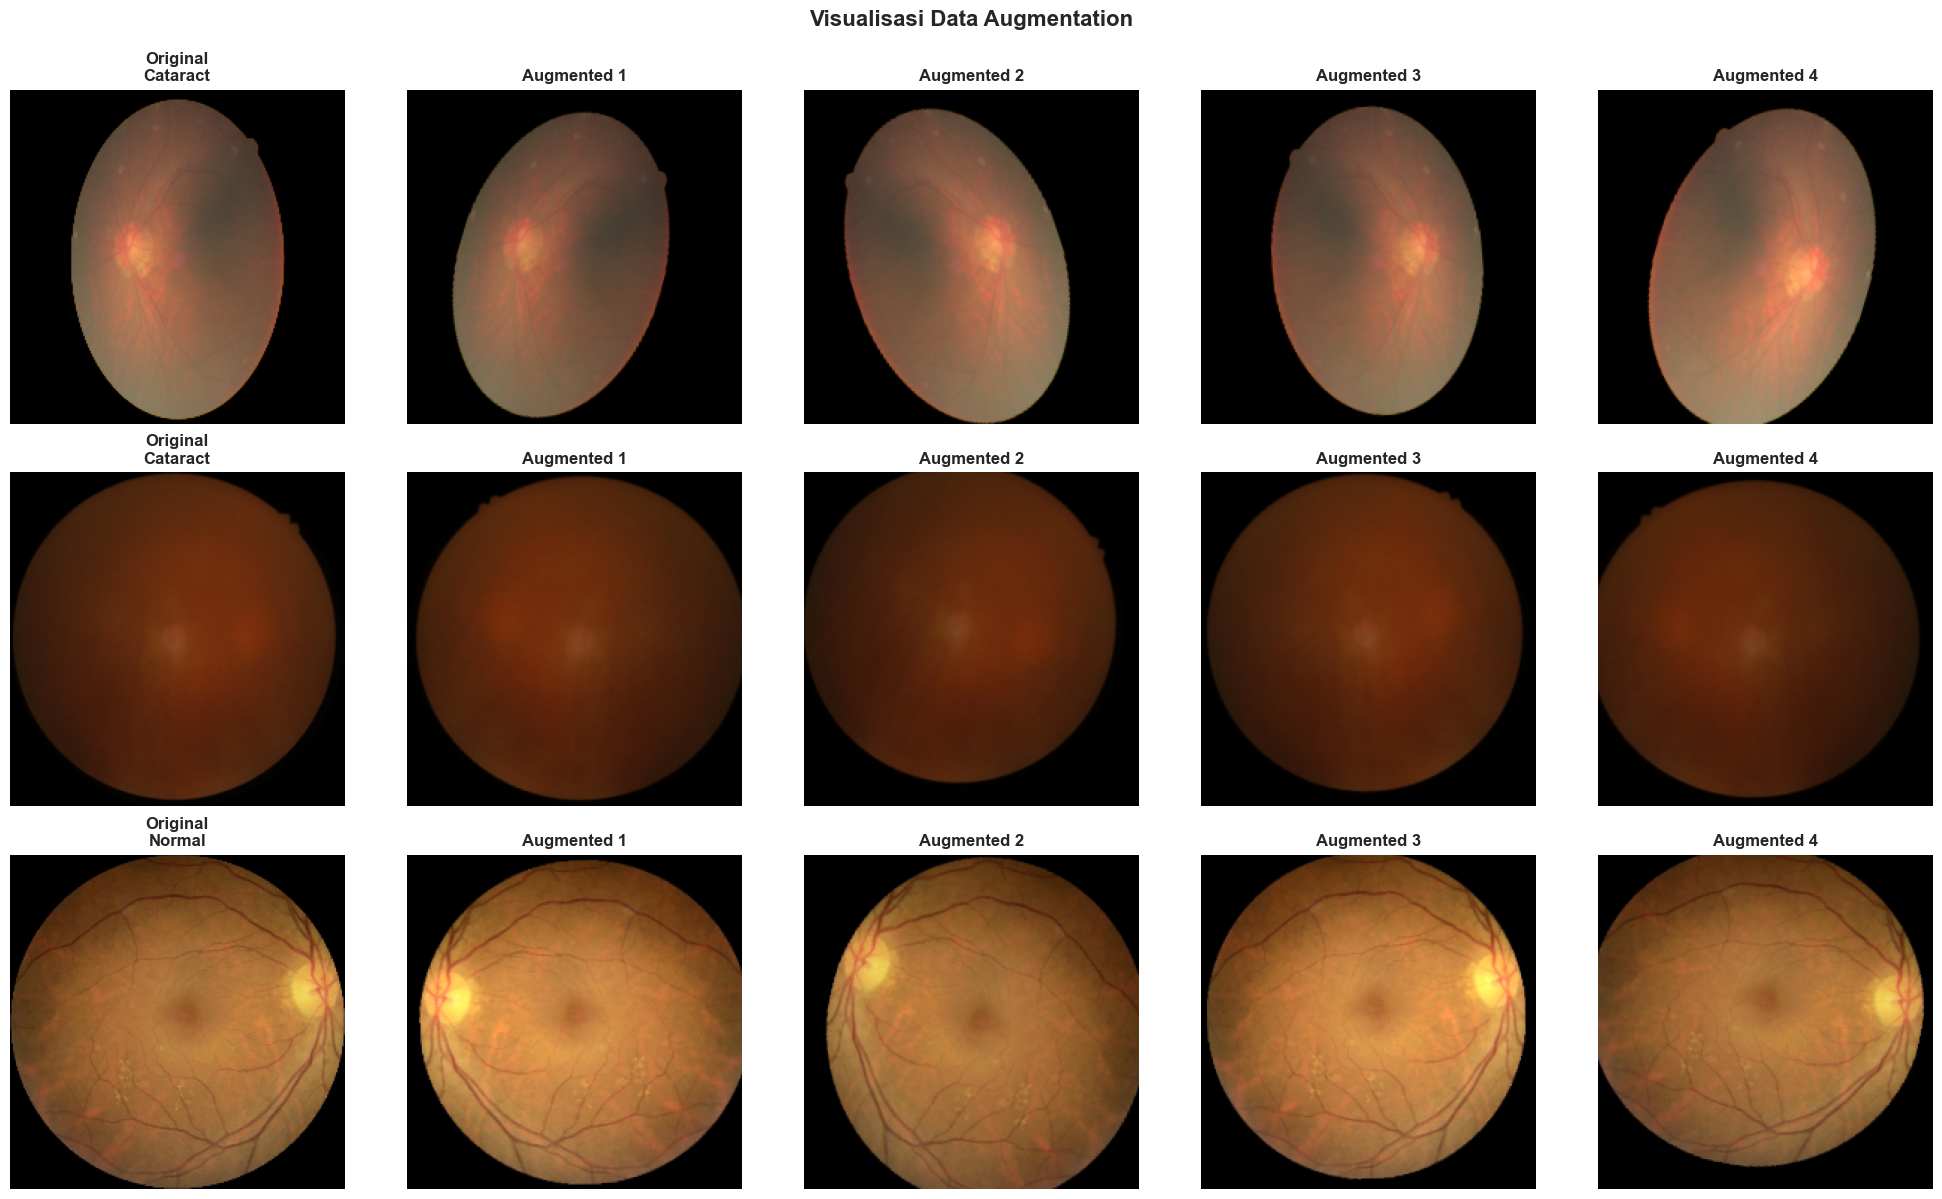


✓ Visualization saved as 'data_augmentation_visualization.png'

SAMPLE BATCH DARI GENERATOR

📊 Generating batch sample visualization...


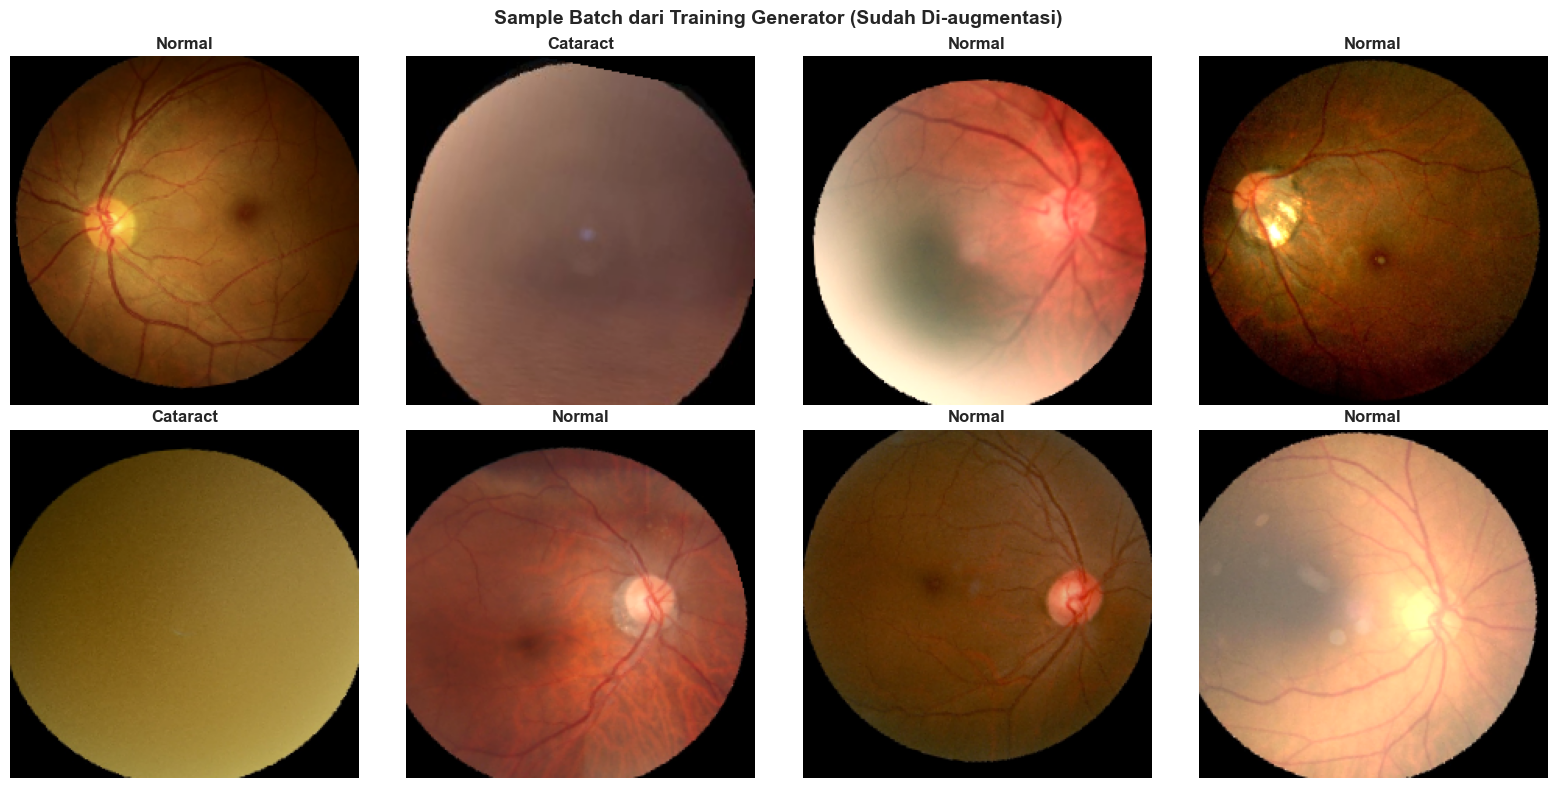


✓ Visualization saved as 'batch_sample_visualization.png'


In [24]:
# ==================== VISUALISASI DATA SETELAH AUGMENTASI ====================
"""
Visualisasi gambar sebelum dan sesudah augmentasi untuk melihat efek preprocessing
"""
print("="*70)
print("VISUALISASI DATA SETELAH AUGMENTASI")
print("="*70)

def visualize_augmentation(train_gen, num_samples=3):
    """
    Visualisasi gambar original vs augmented
    """
    # Get original images
    sample_df = train_df.sample(n=num_samples, random_state=52)
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, 4*num_samples))
    fig.suptitle('Visualisasi Data Augmentation', fontsize=16, fontweight='bold', y=0.995)
    
    for idx, (_, row) in enumerate(sample_df.iterrows()):
        # Load original image
        img_path = row['filepaths']
        label = row['labels']
        
        # Read original
        original_img = cv2.imread(img_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        original_img = cv2.resize(original_img, IMG_SIZE)
        
        # Show original (rescaled only)
        axes[idx, 0].imshow(original_img)
        axes[idx, 0].set_title(f'Original\n{label}', fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Generate augmented versions
        img_array = original_img.reshape((1,) + original_img.shape)
        
        aug_generator = train_datagen.flow(
            img_array,
            batch_size=1
        )
        
        # Show 4 augmented versions
        for i in range(1, 5):
            aug_img = next(aug_generator)[0]
            axes[idx, i].imshow(aug_img)
            axes[idx, i].set_title(f'Augmented {i}', fontweight='bold')
            axes[idx, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('data_augmentation_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved as 'data_augmentation_visualization.png'")

# Visualize
print("\n📊 Generating augmentation visualization...")
print("   Showing 3 samples × 5 versions (1 original + 4 augmented)\n")
visualize_augmentation(train_gen, num_samples=3)

# Show batch examples from generator
print("\n" + "="*70)
print("SAMPLE BATCH DARI GENERATOR")
print("="*70)

def visualize_batch(generator, num_images=8):
    """
    Visualisasi satu batch dari generator
    """
    batch_images, batch_labels = next(generator)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Sample Batch dari Training Generator (Sudah Di-augmentasi)', 
                 fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(batch_images[i])
            label_name = 'Normal' if batch_labels[i] > 0.5 else 'Cataract'
            ax.set_title(f'{label_name}', fontweight='bold')
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('batch_sample_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n✓ Visualization saved as 'batch_sample_visualization.png'")

print("\n📊 Generating batch sample visualization...")
train_gen.reset()
visualize_batch(train_gen, num_images=8)

In [25]:
# ==================== BUILD MODEL ====================
"""
Build MobileNetV2 model dengan transfer learning
"""
print("="*70)
print("BUILDING MOBILENETV2 MODEL")
print("="*70)

# Load pre-trained MobileNetV2
print("\nLoading MobileNetV2 (ImageNet weights)...")
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False
print(f"✓ Base model loaded ({len(base_model.layers)} layers frozen)")

# Build model
print("\nBuilding classification head...")
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

print("✓ Model architecture created")

# Compile
print("\nCompiling model...")
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("✓ Model compiled")

# Model summary
print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
model.summary()

print("\n" + "="*70)
print("MODEL CONFIGURATION")
print("="*70)
print(f"Base Model: MobileNetV2 (ImageNet)")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: Binary Crossentropy")
print(f"Metrics: Accuracy, Precision, Recall, AUC")
print("="*70)

BUILDING MOBILENETV2 MODEL

Loading MobileNetV2 (ImageNet weights)...
✓ Base model loaded (154 layers frozen)

Building classification head...
✓ Model architecture created

Compiling model...
✓ Model compiled

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


MODEL CONFIGURATION
Base Model: MobileNetV2 (ImageNet)
Total parameters: 2,422,081
Trainable parameters: 164,097
Optimizer: Adam (lr=0.001)
Loss: Binary Crossentropy
Metrics: Accuracy, Precision, Recall, AUC


In [26]:
# ==================== TRAINING CALLBACKS ====================
"""
Setup callbacks untuk training
"""
print("="*70)
print("SETTING UP TRAINING CALLBACKS")
print("="*70)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
print("✓ EarlyStopping: patience=5, monitor='val_accuracy'")

# Learning Rate Reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
print("✓ ReduceLROnPlateau: factor=0.5, patience=3")

# Model Checkpoint
checkpoint = ModelCheckpoint(
    'best_cataract_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
print("✓ ModelCheckpoint: save best model")

callbacks = [early_stop, reduce_lr, checkpoint]

print("\n✓ All callbacks configured!")
print("="*70)

SETTING UP TRAINING CALLBACKS
✓ EarlyStopping: patience=5, monitor='val_accuracy'
✓ ReduceLROnPlateau: factor=0.5, patience=3
✓ ModelCheckpoint: save best model

✓ All callbacks configured!


In [27]:
# ==================== TRAIN MODEL ====================
"""
Train the model
"""
print("="*70)
print("TRAINING MODEL")
print("="*70)

EPOCHS = 50
print(f"\nMax epochs: {EPOCHS}")
print(f"Training samples: {len(train_gen)*BATCH_SIZE}")
print(f"Validation samples: {len(val_gen)*BATCH_SIZE}")
print("\nStarting training...\n")

start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*70)
print("TRAINING COMPLETED")
print("="*70)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Epochs completed: {len(history.history['accuracy'])}")
print("="*70)

# Save history
import pickle
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("\n✓ Training history saved to 'training_history.pkl'")

TRAINING MODEL

Max epochs: 50
Training samples: 1504
Validation samples: 320

Starting training...

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.8656 - auc: 0.9235 - loss: 0.3022 - precision: 0.8548 - recall: 0.8548
Epoch 1: val_accuracy improved from -inf to 0.94322, saving model to best_cataract_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.8669 - auc: 0.9246 - loss: 0.2999 - precision: 0.8564 - recall: 0.8563 - val_accuracy: 0.9432 - val_auc: 0.9881 - val_loss: 0.1495 - val_precision: 0.9333 - val_recall: 0.9565 - learning_rate: 0.0010
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - accuracy: 0.9586 - auc: 0.9922 - loss: 0.1059 - precision: 0.9704 - recall: 0.9486
Epoch 2: val_accuracy improved from 0.94322 to 0.94637, saving model to best_cataract_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 989ms/step - accuracy: 0.9585 - auc: 0.9922 - loss: 0.1060 - precision: 0.9702 - recall: 0.9486 - val_accuracy: 0.9464 - val_auc: 0.9919 - val_loss:

VISUALIZING TRAINING HISTORY

Best model at epoch: 8
Best validation accuracy: 0.9685 (96.85%)
Training accuracy: 0.9696 (96.96%)


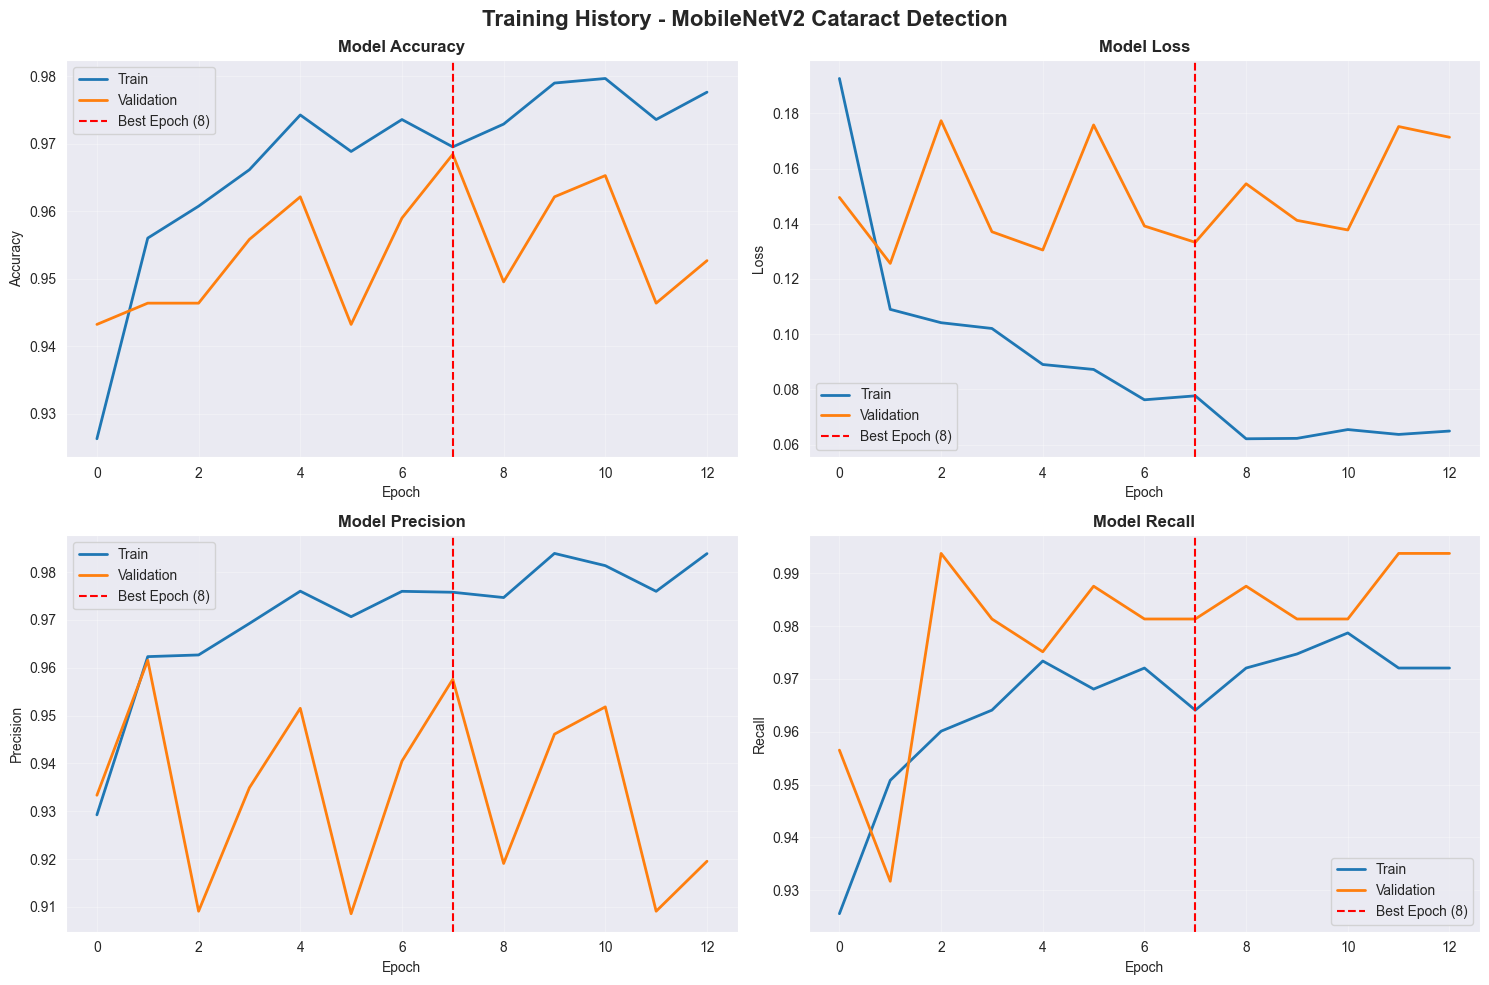


✓ Training history plot saved as 'training_history.png'


In [28]:
# ==================== VISUALIZE TRAINING HISTORY ====================
"""
Plot training & validation metrics
"""
print("="*70)
print("VISUALIZING TRAINING HISTORY")
print("="*70)

# Get best epoch
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_train_acc = history.history['accuracy'][best_epoch]

print(f"\nBest model at epoch: {best_epoch + 1}")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Training accuracy: {best_train_acc:.4f} ({best_train_acc*100:.2f}%)")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training History - MobileNetV2 Cataract Detection', 
             fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0, 0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
axes[0, 0].set_title('Model Accuracy', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0, 1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
axes[0, 1].set_title('Model Loss', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Validation', linewidth=2)
axes[1, 0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
axes[1, 0].set_title('Model Precision', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Validation', linewidth=2)
axes[1, 1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch+1})')
axes[1, 1].set_title('Model Recall', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved as 'training_history.png'")
print("="*70)

FINAL EVALUATION - TEST SET

Loading best model...
✓ Best model loaded (from epoch 8)

Running evaluation on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 667ms/step - accuracy: 0.9611 - auc: 0.9970 - loss: 0.0984 - precision: 0.9298 - recall: 1.0000

TEST SET RESULTS
Test Accuracy:  0.9590 (95.90%)
Test Precision: 0.9253 (92.53%)
Test Recall:    1.0000 (100.00%)
Test AUC:       0.9961
Test Loss:      0.1154
Test F1-Score:  0.9612 (96.12%)

Getting predictions on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 817ms/step
✓ Predictions obtained (317 samples)

CONFUSION MATRIX

                 Predicted
              Cataract  Normal
Actual Cataract   143       13
       Normal       0      161

True Positives (TP):  161 (Normal correctly identified)
True Negatives (TN):  143 (Cataract correctly identified)
False Positives (FP): 13 (Cataract predicted as Normal)
False Negatives (FN): 0 (Normal predicted as Cataract)

Sensitivity (Recall): 1.0000 (100.00%)
Specificity:          0.9167 (91.67%)



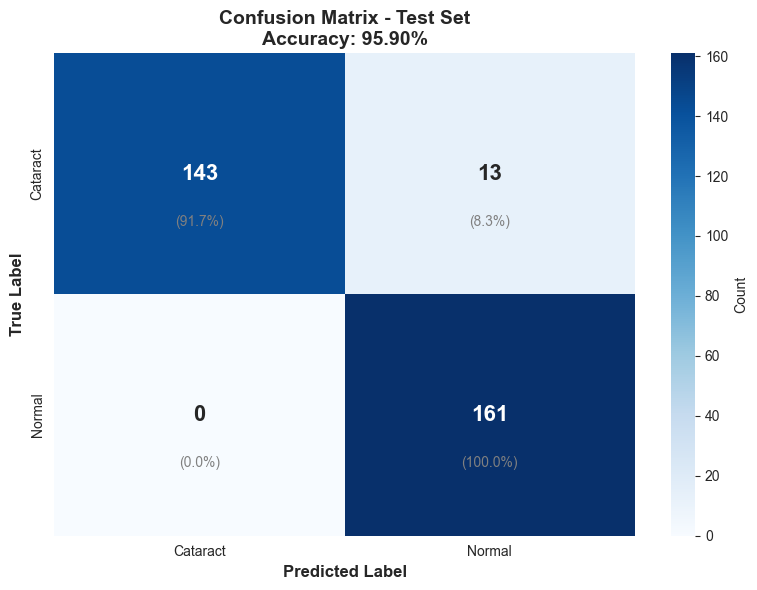


FINAL SUMMARY
✅ Test Accuracy: 95.90%
✅ Validation Accuracy: 96.85%
✅ Train Accuracy: 96.96%

Generalization Check:
  Val - Test gap: 0.95%
  ✅ Excellent! Model generalizes well!

✓ Evaluation complete!
✓ Files saved:
  • best_cataract_model.keras
  • training_history.png
  • training_history.pkl
  • confusion_matrix_test.png
  • data_augmentation_visualization.png
  • batch_sample_visualization.png


In [29]:
# ==================== EVALUATE ON TEST SET ====================
"""
Evaluasi final pada test set (data yang belum pernah dilihat)
"""
print("="*70)
print("FINAL EVALUATION - TEST SET")
print("="*70)

# Load best model
print("\nLoading best model...")
best_model = keras.models.load_model('best_cataract_model.keras')
print("✓ Best model loaded (from epoch {})".format(best_epoch + 1))

# Evaluate on test set
print("\n" + "="*70)
print("Running evaluation on test set...")
print("="*70)

test_results = best_model.evaluate(test_gen, verbose=1)

test_loss = test_results[0]
test_acc = test_results[1]
test_prec = test_results[2]
test_rec = test_results[3]
test_auc = test_results[4]

print("\n" + "="*70)
print("TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision: {test_prec:.4f} ({test_prec*100:.2f}%)")
print(f"Test Recall:    {test_rec:.4f} ({test_rec*100:.2f}%)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Loss:      {test_loss:.4f}")

# Calculate F1-Score
f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec)
print(f"Test F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

print("="*70)

# Get predictions
print("\nGetting predictions on test set...")
test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(f"✓ Predictions obtained ({len(y_pred)} samples)")

# Confusion Matrix
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_true, y_pred)
class_names = ['Cataract', 'Normal']

print("\n                 Predicted")
print("              Cataract  Normal")
print(f"Actual Cataract   {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Normal     {cm[1,0]:3d}      {cm[1,1]:3d}")

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Positives (TP):  {tp} (Normal correctly identified)")
print(f"True Negatives (TN):  {tn} (Cataract correctly identified)")
print(f"False Positives (FP): {fp} (Cataract predicted as Normal)")
print(f"False Negatives (FN): {fn} (Normal predicted as Cataract)")

# Additional metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nSensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity:          {specificity:.4f} ({specificity*100:.2f}%)")

print("\n💡 Medical Context:")
print(f"  • Sensitivity: Kemampuan detect Normal correctly")
print(f"  • Specificity: Kemampuan detect Cataract correctly")
print("="*70)

# Classification Report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Visualize Confusion Matrix
print("\nPlotting confusion matrix...")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax, 
            annot_kws={'size': 16, 'weight': 'bold'})

ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold', fontsize=12)
ax.set_title(f'Confusion Matrix - Test Set\nAccuracy: {test_acc*100:.2f}%', 
             fontweight='bold', fontsize=14)

# Add percentages
for i in range(2):
    for j in range(2):
        total = cm[i].sum()
        percentage = cm[i, j] / total * 100
        ax.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
               ha='center', va='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"✅ Train Accuracy: {best_train_acc*100:.2f}%")
print(f"\nGeneralization Check:")
print(f"  Val - Test gap: {abs(best_val_acc - test_acc)*100:.2f}%")
if abs(best_val_acc - test_acc) < 0.03:
    print("  ✅ Excellent! Model generalizes well!")
elif abs(best_val_acc - test_acc) < 0.05:
    print("  ✓ Good! Model generalizes well!")
else:
    print("  ⚠ Gap > 5%, check for issues")
print("="*70)

print("\n✓ Evaluation complete!")
print("✓ Files saved:")
print("  • best_cataract_model.keras")
print("  • training_history.png")
print("  • training_history.pkl")
print("  • confusion_matrix_test.png")
print("  • data_augmentation_visualization.png")
print("  • batch_sample_visualization.png")